<a href="https://colab.research.google.com/github/KaustubhSN12/deep_learning_exercise/blob/main/DL_P4_Implement_Convolutional_Neural_Network_for_Digit_Recognition_on_the_MNIST_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
#load the data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape to (samples, 28, 28, 1) and normalize
x_train = x_train.reshape(-1,28,28,1).astype("float32")/255.0
x_test = x_test.reshape(-1,28,28,1).astype("float32")/255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Convert labels to one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
# 2. Build the CNN model
model = Sequential()

# Conv Layer 1
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
# MaxPooling
model.add(MaxPooling2D(pool_size=(2, 2)))

# Conv Layer 2
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
# MaxPooling
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten and Dense layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))  # Regularization
model.add(Dense(10, activation='softmax'))  # Output layer for 10 classes

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 3. Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# train the model
model.fit(x_train, y_train,
          batch_size=128,
          epochs=5,
          validation_data=(x_test, y_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 89ms/step - accuracy: 0.8013 - loss: 0.6400 - val_accuracy: 0.9811 - val_loss: 0.0617
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 89ms/step - accuracy: 0.9697 - loss: 0.1032 - val_accuracy: 0.9876 - val_loss: 0.0405
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 90ms/step - accuracy: 0.9777 - loss: 0.0735 - val_accuracy: 0.9882 - val_loss: 0.0372
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 90ms/step - accuracy: 0.9817 - loss: 0.0585 - val_accuracy: 0.9903 - val_loss: 0.0276
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 85s 95ms/step - accuracy: 0.9852 - loss: 0.0471 - val_accuracy: 0.9911 - val_loss: 0.0253
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 79s 90ms/step - accuracy: 0.9865 - loss: 0.0420 - val_accuracy: 0.9892 - val_loss: 0.0331
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 87ms/step - accuracy: 0.9889 - loss: 0.0372 - val_accuracy: 0.9920 - val_loss: 0.0242
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 89ms/step - accuracy: 0.9910 - loss: 0.0322 - 

In [ ]:
# 5. Evaluate the model
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# 6. Predict and visualize some results
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9901 - loss: 0.0310
Test Accuracy: 0.9925
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


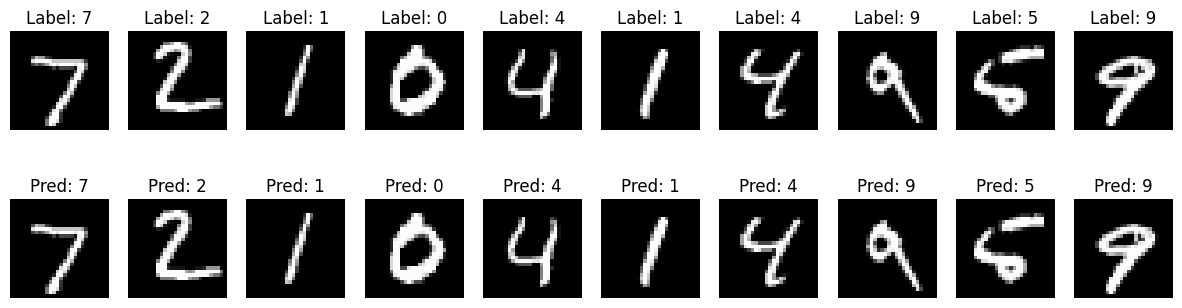

In [ ]:
# Visualize first 10 predictions
plt.figure(figsize=(15, 4))
for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    plt.title("Label: " + str(np.argmax(y_test[i])))

    plt.subplot(2, 10, i + 11)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    plt.title("Pred: " + str(np.argmax(predictions[i])))
plt.show()